# 🏠 Análisis de Datos — Inmuebles en Madrid (datos de Idealista)
**Proyecto:** MFR - Analisis de datos  
**Dataset:** `houses_Madrid.csv`  
**Objetivo:** Identificar las variables que más influyen en el **precio de venta** (`buy_price`) de inmuebles en Madrid.

---
## Metodología EDA
1. Data Wrangling (nulos, duplicados, outliers)
2. Datos categóricos
3. Análisis Univariado
4. Outliers & BoxPlot
5. Análisis Bivariado
6. Análisis de Correlación
7. Conclusiones e Insights de Negocio


## 0. Importación de librerías y carga de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import pearsonr, spearmanr
from pathlib import Path

print('✓ Libraries loaded successfully')

✓ Libraries loaded successfully


In [2]:
# Configurar Pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [3]:
# Estilo general
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (10, 5)})

# ── Carga de datos ──
df_raw = pd.read_csv("data/houses_Madrid.csv")
print(f"Dataset cargado: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas")
df_raw.head(3)

Dataset cargado: 21,742 filas × 58 columnas


,Unnamed: 0,id,title,subtitle,sq_mt_built,sq_mt_useful,n_rooms,n_bathrooms,n_floors,sq_mt_allotment,latitude,longitude,raw_address,is_exact_address_hidden,street_name,street_number,portal,floor,is_floor_under,door,neighborhood_id,operation,rent_price,rent_price_by_area,is_rent_price_known,buy_price,buy_price_by_area,is_buy_price_known,house_type_id,is_renewal_needed,is_new_development,built_year,has_central_heating,has_individual_heating,are_pets_allowed,has_ac,has_fitted_wardrobes,has_lift,is_exterior,has_garden,has_pool,has_terrace,has_balcony,has_storage_room,is_furnished,is_kitchen_equipped,is_accessible,has_green_zones,energy_certificate,has_parking,has_private_parking,has_public_parking,is_parking_included_in_price,parking_price,is_orientation_north,is_orientation_west,is_orientation_south,is_orientation_east
0,0,21742,"Piso en venta en calle de Godella, 64","San Cristóbal, Madrid",64.00,60.00,2,1.00,NaN,NaN,NaN,NaN,"Calle de Godella, 64",False,Calle de Godella,64,NaN,3,False,NaN,Neighborhood 135: San Cristóbal (1308.89 €/m2)...,sale,471,NaN,False,85000,1328,True,HouseType 1: Pisos,False,False,1960.00,NaN,NaN,NaN,True,NaN,False,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,D,False,NaN,NaN,NaN,NaN,False,True,False,False
1,1,21741,Piso en venta en calle de la del Manojo de Rosas,"Los Ángeles, Madrid",70.00,NaN,3,1.00,NaN,NaN,NaN,NaN,Calle de la del Manojo de Rosas,True,Calle de la del Manojo de Rosas,NaN,NaN,4,False,NaN,Neighborhood 132: Los Ángeles (1796.68 €/m2) -...,sale,666,NaN,False,129900,1856,True,HouseType 1: Pisos,True,False,NaN,NaN,NaN,NaN,NaN,True,True,True,NaN,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,en trámite,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,21740,"Piso en venta en calle del Talco, 68","San Andrés, Madrid",94.00,54.00,2,2.00,NaN,NaN,NaN,NaN,"Calle del Talco, 68",False,Calle del Talco,68,NaN,1,False,NaN,Neighborhood 134: San Andrés (1617.18 €/m2) - ...,sale,722,NaN,False,144247,1535,True,HouseType 1: Pisos,False,False,NaN,False,True,NaN,NaN,True,True,True,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN,NaN,no indicado,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 1. Data Wrangling

### 1.1 Visión general del dataset


In [4]:
# Data quality overview

print('=== Instantánea de la calidad de los datos ===')
quality = pd.DataFrame({
    'dtype':        df_raw.dtypes,
    'non_null':     df_raw.count(),
    'missing':      df_raw.isnull().sum(),
    'missing_%':    (df_raw.isnull().mean() * 100).round(1),
    'unique':       df_raw.nunique(),
    'unique_%':     (df_raw.nunique() / len(df_raw) * 100).round(1),
})
print(quality.to_string())

=== Instantánea de la calidad de los datos ===
                                dtype  non_null  missing  missing_%  unique  unique_%
Unnamed: 0                      int64     21742        0       0.00   21742    100.00
id                              int64     21742        0       0.00   21742    100.00
title                          object     21742        0       0.00   10736     49.40
subtitle                       object     21742        0       0.00     146      0.70
sq_mt_built                   float64     21616      126       0.60     678      3.10
sq_mt_useful                  float64      8228    13514      62.20     408      1.90
n_rooms                         int64     21742        0       0.00      19      0.10
n_bathrooms                   float64     21726       16       0.10      16      0.10
n_floors                      float64      1437    20305      93.40       6      0.00
sq_mt_allotment               float64      1432    20310      93.40     356      1.60
latitud

### 1.2 Análisis de datos nulos

=== Analisis de datos nulos por columna ===


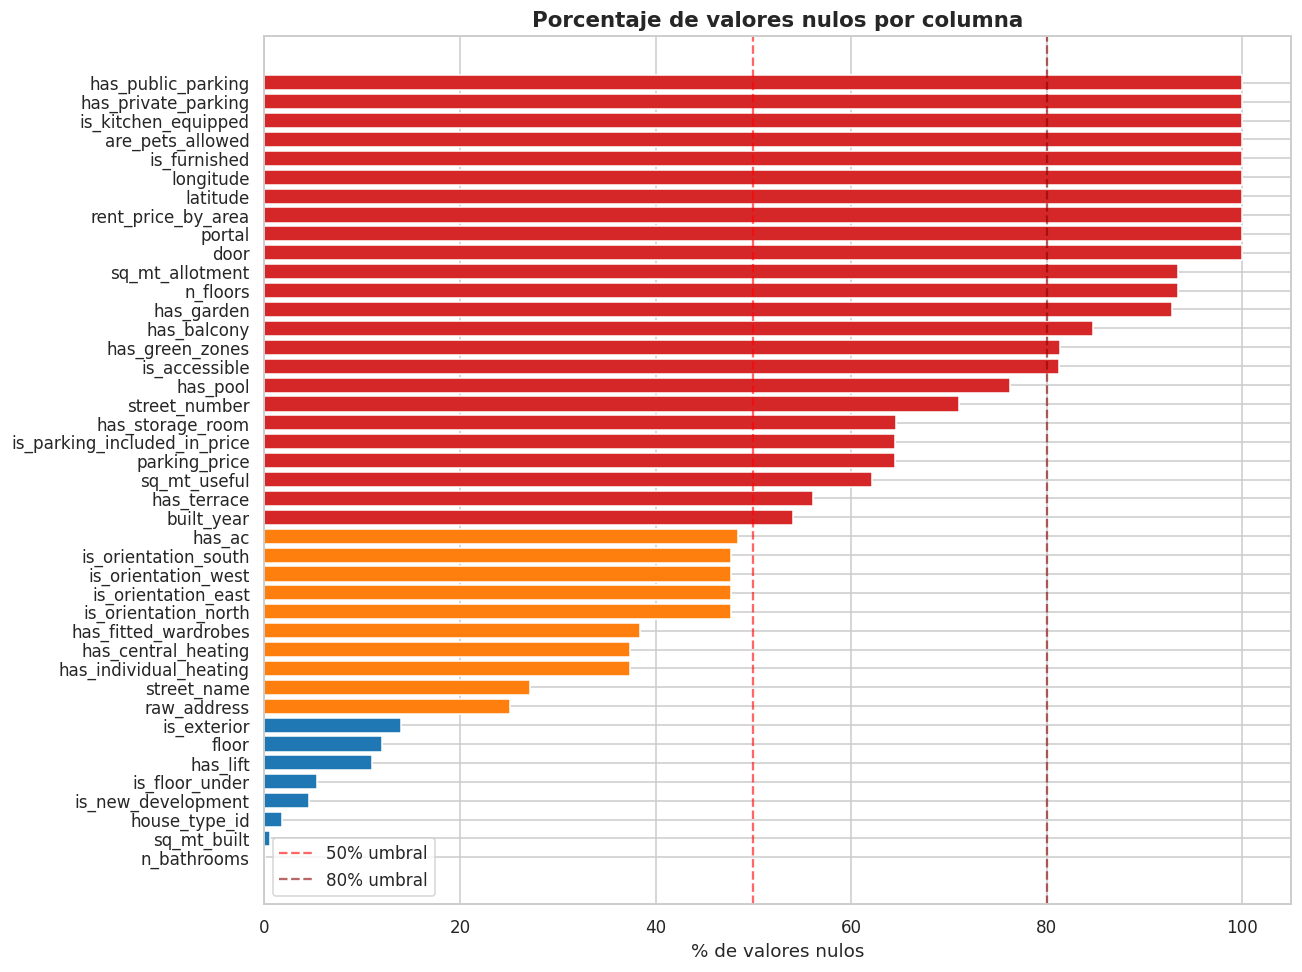

                     columna  % nulos
                 n_bathrooms     0.07
                 sq_mt_built     0.58
               house_type_id     1.80
          is_new_development     4.56
              is_floor_under     5.38
                    has_lift    10.97
                       floor    11.99
                 is_exterior    14.00
                 raw_address    25.14
                 street_name    27.16
      has_individual_heating    37.41
         has_central_heating    37.41
        has_fitted_wardrobes    38.37
        is_orientation_north    47.76
         is_orientation_east    47.76
         is_orientation_west    47.76
        is_orientation_south    47.76
                      has_ac    48.44
                  built_year    54.01
                 has_terrace    56.08
                sq_mt_useful    62.16
               parking_price    64.50
is_parking_included_in_price    64.50
            has_storage_room    64.59
               street_number    71.02
            

In [5]:
print('=== Analisis de datos nulos por columna ===')
nulos = (df_raw.isnull().sum() / len(df_raw) * 100).sort_values(ascending=True)
nulos_df = nulos[nulos > 0].reset_index()
nulos_df.columns = ["columna", "% nulos"]

fig, ax = plt.subplots(figsize=(12, 9))
colors = ["#d62728" if x > 50 else "#ff7f0e" if x > 20 else "#1f77b4"
          for x in nulos_df["% nulos"]]
ax.barh(nulos_df["columna"], nulos_df["% nulos"], color=colors)
ax.set_xlabel("% de valores nulos")
ax.set_title("Porcentaje de valores nulos por columna", fontsize=14, fontweight="bold")
ax.axvline(50, color="red", linestyle="--", alpha=0.6, label="50% umbral")
ax.axvline(80, color="darkred", linestyle="--", alpha=0.6, label="80% umbral")
ax.legend()
plt.tight_layout()
plt.savefig("img/fig_nulos.png", bbox_inches="tight")
plt.show()
print(nulos_df.to_string(index=False))


### 1.3 Duplicados

In [6]:
dups = df_raw.duplicated().sum()
print(f"Filas duplicadas: {dups}")
print("→ No se requiere acción." if dups == 0 else f"→ Se eliminarán {dups} duplicados.")


Filas duplicadas: 0
→ No se requiere acción.


### 1.4 Tratamiento de nulos y construcción del DataFrame limpio

**Criterios de tratamiento (siguiendo EDA):**

| Columna | Tratamiento | Justificación |
|---------|-------------|---------------|
| `latitude`, `longitude`, `door`, `portal`, `rent_price_by_area`, `has_private_parking`, `is_kitchen_equipped`, `is_furnished`, `has_public_parking`, `are_pets_allowed` | **Eliminar columna** | 100% nulos — sin información |
| Columnas con >80% nulos (balcony, green_zones, accessible, pool, allotment, n_floors, garden) | **Eliminar columna** | Muy poco representativas |
| `sq_mt_built` | **Eliminar filas** | No se puede estimar precio sin m² |
| `n_bathrooms` | **Imputar con 1** | Mínimo esperado en cualquier inmueble |
| `floor` | **Imputar con '1'** | Valor más frecuente; nan=desconocido |
| `house_type_id` | **Imputar con 0** | Pisos es el tipo más común |
| `built_year` | **Eliminar columna** | 54% nulos — alta incertidumbre |
| Variables booleanas con nulos | **Imputar con False (0)** | Ausencia de información = no tiene la característica |
| `is_exterior`, `has_lift` | **Imputar con False** | Misma lógica |


In [7]:
# ── Copia de trabajo o backup ──
df = df_raw.copy()

# 1) Eliminar columnas 100% nulas y no analiticas
cols_drop_100pct = [
    "latitude", "longitude", "door", "portal",
    "rent_price_by_area", "has_private_parking",
    "is_kitchen_equipped", "is_furnished",
    "has_public_parking", "are_pets_allowed",
    "Unnamed: 0", "id", "title", "subtitle",
    "raw_address", "street_name", "street_number",
    "is_exact_address_hidden", "is_floor_under",
    "operation",              # todas son 'sale'
    "is_rent_price_known",    # todas False
    "built_year",             # 54% nulos
    "sq_mt_allotment",        # 93% nulos
    "n_floors",               # 93% nulos
    "has_garden",             # 93% nulos
    "has_balcony",            # 85% nulos
    "has_green_zones",        # 81% nulos
    "is_accessible",          # 81% nulos
    "has_pool",               # 76% nulos
    "has_storage_room",       # 65% nulos
    "is_parking_included_in_price",  # 64% nulos
    "parking_price",          # 64% nulos
    "sq_mt_useful",           # 62% nulos
    "has_terrace",            # 56% nulos
    "buy_price_by_area",      # derivada de buy_price
    "rent_price",             # no es la variable objetivo principal; todos sin precio conocido
    "is_rent_price_known",
]
cols_drop_100pct = [c for c in cols_drop_100pct if c in df.columns]
df.drop(columns=cols_drop_100pct, inplace=True)

# 2) Eliminar filas con sq_mt_built nulo (imposible estimar precio sin m²)
antes = len(df)
df.dropna(subset=["sq_mt_built"], inplace=True)
print(f"Filas eliminadas por sq_mt_built nulo: {antes - len(df)}")

# 3) Imputaciones
df["n_rooms"] = df["n_rooms"].fillna(1)
df["n_bathrooms"] = df["n_bathrooms"].fillna(1)
df["house_type_id"] = df["house_type_id"].fillna(df["house_type_id"].mode()[0])
df["is_buy_price_known"] = df["is_buy_price_known"].fillna(False)
df["is_new_development"] = df["is_new_development"].fillna(False)
df["is_renewal_needed"] = df["is_renewal_needed"].fillna(False)

# 3.1) floor (Tratamiento directo en la misma columna)
# Paso A: Imputar nulos (nan) con el string '1' para poder procesar el texto libremente
df['floor'] = df['floor'].fillna('1')
# Paso B: Convertir a cadena limpia en minúsculas para evitar fallos de coincidencia
df['floor'] = df['floor'].astype(str).str.lower().str.strip()

# 3.2) Booleanas como object → imputar con 'False'
bool_obj_cols = ["has_central_heating", "has_individual_heating",
                 "has_ac", "has_fitted_wardrobes",
                 "has_parking", "is_orientation_north",
                 "is_orientation_west", "is_orientation_south",
                 "is_orientation_east"]
for col in bool_obj_cols:
    if col in df.columns:
        df[col] = df[col].fillna("False")

# has_lift y is_exterior (bool con nulos)
for col in ["has_lift", "is_exterior"]:
    if col in df.columns:
        df[col] = df[col].fillna(False)

# 4) Extraer distrito del neighborhood_id
df["district"] = df["neighborhood_id"].str.extract(r"District \d+: ([^)]+)")
df["district"] = df["district"].str.strip()


Filas eliminadas por sq_mt_built nulo: 126


In [8]:
print('=== Conversion de tipo de dato de object a bool ===')
bool_cols = [
        'has_central_heating',
        'has_individual_heating',
        'has_ac',
        'has_fitted_wardrobes',
        'is_orientation_north',
        'is_orientation_west',
        'is_orientation_south',
        'is_orientation_east'
    ]

for col in bool_cols:
  if col in df.columns:
      # Paso A: Imputar los valores nulos (NaN) con False
      df[col] = df[col].fillna(False)
      df[col] = df[col].apply(
              lambda x: True if str(x).lower() in ['true', '1', '1.0', 'yes', 'si', 'sí'] else False
            )
            # Paso C: Forzar el tipo de dato nativo a bool
      df[col] = df[col].astype(bool)

=== Conversion de tipo de dato de object a bool ===


In [9]:
# Paso C: Función interna para evaluar las condiciones de floor
def mapear_floor_directo(val):
        if val == 'bajo':
            return 0
        elif 'sotano' in val or 'sótano' in val:
            return -1
        elif 'entreplanta' in val:
            return 1

        # Si es un piso estándar (ej. "3", "4º", "2ª"), extraemos solo los dígitos
        numeros = ''.join([c for c in val if c.isdigit()])
        if numeros:
            return int(numeros)

        # En caso de cualquier otro texto imprevisto, se imputa con 1
        return 1

In [10]:
# Convertir explícitamente las variables
df['n_bathrooms'] = df['n_bathrooms'].astype(int)
df['buy_price'] = df['buy_price'].astype(float).round(2)
df['floor'] = df['floor'].apply(mapear_floor_directo).astype(int)

In [11]:
print(f"\nDataFrame limpio: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Nulos restantes: {df.isnull().sum().sum()}")
df.info()


DataFrame limpio: 21,616 filas × 23 columnas
Nulos restantes: 0
<class 'pandas.core.frame.DataFrame'>
Index: 21616 entries, 0 to 21741
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   sq_mt_built             21616 non-null  float64
 1   n_rooms                 21616 non-null  int64  
 2   n_bathrooms             21616 non-null  int64  
 3   floor                   21616 non-null  int64  
 4   neighborhood_id         21616 non-null  object 
 5   buy_price               21616 non-null  float64
 6   is_buy_price_known      21616 non-null  bool   
 7   house_type_id           21616 non-null  object 
 8   is_renewal_needed       21616 non-null  bool   
 9   is_new_development      21616 non-null  bool   
 10  has_central_heating     21616 non-null  bool   
 11  has_individual_heating  21616 non-null  bool   
 12  has_ac                  21616 non-null  bool   
 13  has_fitted_wardrobes    21616 n

In [12]:
# Visualizar el dataset limpio df
df.head()

,sq_mt_built,n_rooms,n_bathrooms,floor,neighborhood_id,buy_price,is_buy_price_known,house_type_id,is_renewal_needed,is_new_development,has_central_heating,has_individual_heating,has_ac,has_fitted_wardrobes,has_lift,is_exterior,energy_certificate,has_parking,is_orientation_north,is_orientation_west,is_orientation_south,is_orientation_east,district
0,64.00,2,1,3,Neighborhood 135: San Cristóbal (1308.89 €/m2)...,85000.00,True,HouseType 1: Pisos,False,False,False,False,True,False,False,True,D,False,False,True,False,False,Villaverde
1,70.00,3,1,4,Neighborhood 132: Los Ángeles (1796.68 €/m2) -...,129900.00,True,HouseType 1: Pisos,True,False,False,False,False,True,True,True,en trámite,False,False,False,False,False,Villaverde
2,94.00,2,2,1,Neighborhood 134: San Andrés (1617.18 €/m2) - ...,144247.00,True,HouseType 1: Pisos,False,False,False,True,False,True,True,True,no indicado,False,False,False,False,False,Villaverde
3,64.00,2,1,0,Neighborhood 134: San Andrés (1617.18 €/m2) - ...,109900.00,True,HouseType 1: Pisos,False,False,False,False,False,False,True,True,en trámite,False,False,False,True,False,Villaverde
4,108.00,2,2,4,Neighborhood 133: Los Rosales (1827.79 €/m2) -...,260000.00,True,HouseType 1: Pisos,False,False,False,False,True,True,True,True,en trámite,True,True,True,True,True,Villaverde


In [13]:
ruta_salida = "data/db_madrid_idealista.csv"

#  Guardar el DataFrame en formato CSV
df.to_csv(
    ruta_salida,
    index=False,         # EVITA que se guarde una columna extra con los números de fila (0, 1, 2...)
    sep=',',             # Define el separador de campos (coma por defecto)
    encoding='utf-8'     # Asegura que los acentos y caracteres especiales se guarden correctamente
)

print(f"✅ ¡Dataset guardado con éxito en: {ruta_salida}!")

✅ ¡Dataset guardado con éxito en: data/db_madrid_idealista.csv!


In [15]:
#### ¿Cómo se plantea esta Prueba de Hipótesis? ###

def probar_hipotesis_correlacion(df, columna_x, variable_objetivo='buy_price', alpha=0.05):
    print(f"📊 PRUEBA DE HIPÓTESIS: {columna_x} vs {variable_objetivo}")
    print("-" * 55)
    print("H0: No existe correlación lineal significativa entre las variables (r = 0).")
    print("H1: Existe una correlación lineal significativa entre las variables (r != 0).")

    # Eliminar nulos temporalmente para la prueba
    df_temp = df[[columna_x, variable_objetivo]].dropna()

    # Calcular correlación y p-valor
    r_coef, p_value = pearsonr(df_temp[columna_x], df_temp[variable_objetivo])

    print(f"-> Coeficiente de correlación (r): {r_coef:.4f}")
    print(f"-> P-valor calculado: {p_value}")

    # Conclusión formal del contraste
    if p_value < alpha:
        print(f"💥 CONCLUSIÓN: Dado que el p-valor ({p_value}) < alpha ({alpha}), RECHAZAMOS la Hipótesis Nula (H0).")
        print(f"✅ Hay evidencia estadística suficiente para afirmar que {columna_x} influye significativamente en el precio de alquiler.")
    else:
        print(f"🛑 CONCLUSIÓN: Dado que el p-valor ({p_value}) >= alpha ({alpha}), NO RECHAZAMOS la Hipótesis Nula (H0).")
        print(f"⚠️ No se puede afirmar que exista una relación lineal significativa con los datos actuales.")
    print("=" * 55 + "\n")

# --- Ejecución para tus variables independientes clave ---
variables_clave = ['sq_mt_built', 'n_bathrooms', 'n_rooms', 'floor']

for var in variables_clave:
    if var in df.columns:
        probar_hipotesis_correlacion(df, var)

📊 PRUEBA DE HIPÓTESIS: sq_mt_built vs buy_price
-------------------------------------------------------
H0: No existe correlación lineal significativa entre las variables (r = 0).
H1: Existe una correlación lineal significativa entre las variables (r != 0).
-> Coeficiente de correlación (r): 0.8320
-> P-valor calculado: 0.0
💥 CONCLUSIÓN: Dado que el p-valor (0.0) < alpha (0.05), RECHAZAMOS la Hipótesis Nula (H0).
✅ Hay evidencia estadística suficiente para afirmar que sq_mt_built influye significativamente en el precio de alquiler.

📊 PRUEBA DE HIPÓTESIS: n_bathrooms vs buy_price
-------------------------------------------------------
H0: No existe correlación lineal significativa entre las variables (r = 0).
H1: Existe una correlación lineal significativa entre las variables (r != 0).
-> Coeficiente de correlación (r): 0.7583
-> P-valor calculado: 0.0
💥 CONCLUSIÓN: Dado que el p-valor (0.0) < alpha (0.05), RECHAZAMOS la Hipótesis Nula (H0).
✅ Hay evidencia estadística suficiente para 

---
## 2. Análisis Univariado

### 2.1 Variable objetivo: `buy_price`


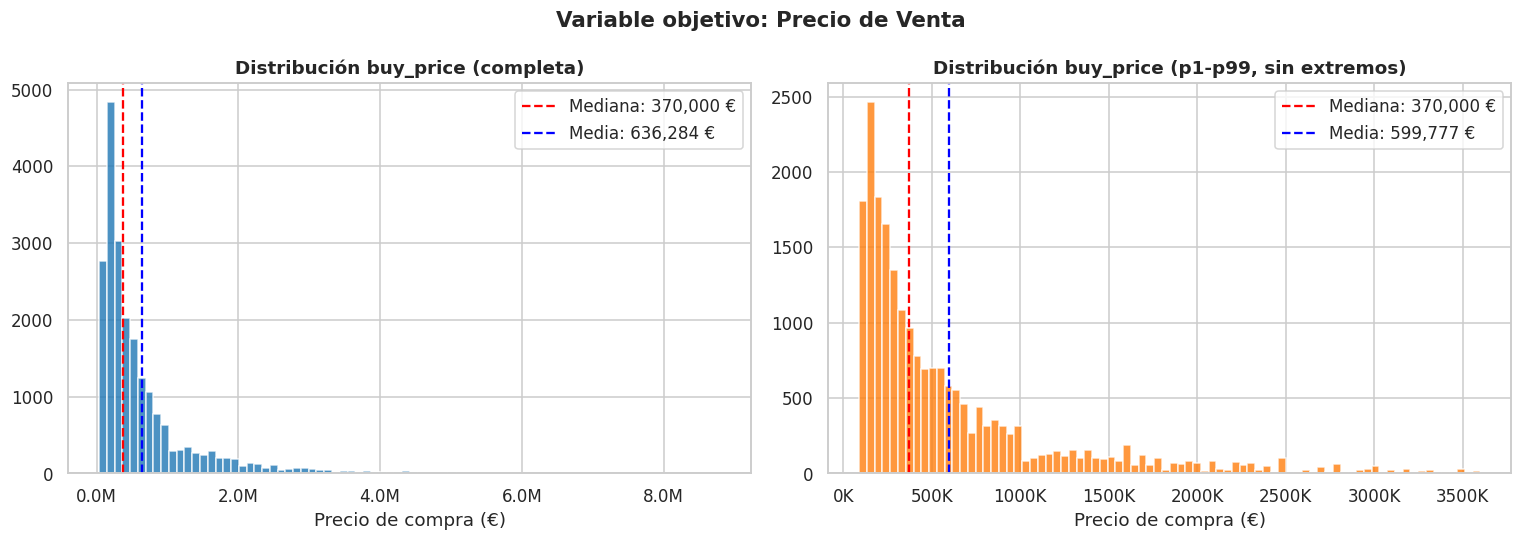

=== Estadísticas descriptivas: buy_price ===
count     21616.00
mean     636284.02
std      743318.84
min       36000.00
25%      198000.00
50%      370000.00
75%      750000.00
max     8800000.00
Name: buy_price, dtype: float64

Coeficiente de asimetría (skewness): 3.320
Kurtosis: 17.622
→ Distribución fuertemente asimétrica a la derecha (positiva)


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma completo
axes[0].hist(df["buy_price"], bins=80, color="#1f77b4", edgecolor="white", alpha=0.8)
axes[0].set_title("Distribución buy_price (completa)", fontweight="bold")
axes[0].set_xlabel("Precio de compra (€)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
axes[0].axvline(df["buy_price"].median(), color="red", linestyle="--", label=f"Mediana: {df['buy_price'].median():,.0f} €")
axes[0].axvline(df["buy_price"].mean(), color="blue", linestyle="--", label=f"Media: {df['buy_price'].mean():,.0f} €")
axes[0].legend()

# Sin extremos (p1-p99)
p1, p99 = df["buy_price"].quantile([0.01, 0.99])
df_filt = df[(df["buy_price"] >= p1) & (df["buy_price"] <= p99)]
axes[1].hist(df_filt["buy_price"], bins=80, color="#ff7f0e", edgecolor="white", alpha=0.8)
axes[1].set_title("Distribución buy_price (p1-p99, sin extremos)", fontweight="bold")
axes[1].set_xlabel("Precio de compra (€)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
axes[1].axvline(df_filt["buy_price"].median(), color="red", linestyle="--",
                label=f"Mediana: {df_filt['buy_price'].median():,.0f} €")
axes[1].axvline(df_filt["buy_price"].mean(), color="blue", linestyle="--",
                label=f"Media: {df_filt['buy_price'].mean():,.0f} €")
axes[1].legend()

plt.suptitle("Variable objetivo: Precio de Venta", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("img/fig_buy_price_hist.png", bbox_inches="tight")
plt.show()

# Estadísticas descriptivas
print("=== Estadísticas descriptivas: buy_price ===")
desc = df["buy_price"].describe()
print(desc)
print(f"\nCoeficiente de asimetría (skewness): {df['buy_price'].skew():.3f}")
print(f"Kurtosis: {df['buy_price'].kurtosis():.3f}")
print("→ Distribución fuertemente asimétrica a la derecha (positiva)")


In [18]:
# Perfil univariado: variables numéricas

num_cols = df.select_dtypes(include='number').columns.tolist()
print(f'Columnas numéricas: {num_cols}')

# Descripción extendida: añade asimetría y curtosis.
num_profile = df[num_cols].describe().T
num_profile['skewness'] = df[num_cols].skew().round(2)
num_profile['kurtosis'] = df[num_cols].kurt().round(2)
num_profile['cv_%']     = (df[num_cols].std() / df[num_cols].mean() * 100).round(1)  # coefficient of variation

print('\nPerfil de variable numérica:')
num_profile.round(2)

Columnas numéricas: ['sq_mt_built', 'n_rooms', 'n_bathrooms', 'floor', 'buy_price']

Perfil de variable numérica:


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,cv_%
sq_mt_built,21616.00,146.92,134.18,13.00,70.00,100.00,162.00,999.00,2.77,9.41,91.30
n_rooms,21616.00,2.98,1.47,0.00,2.00,3.00,4.00,24.00,1.34,8.73,49.20
n_bathrooms,21616.00,2.06,1.33,1.00,1.00,2.00,2.00,14.00,1.83,4.21,64.70
floor,21616.00,2.43,1.99,-1.00,1.00,2.00,4.00,9.00,1.03,0.60,82.00
buy_price,21616.00,636284.02,743318.84,36000.00,198000.00,370000.00,750000.00,8800000.00,3.32,17.62,116.80


### 2.2 Variables numéricas clave

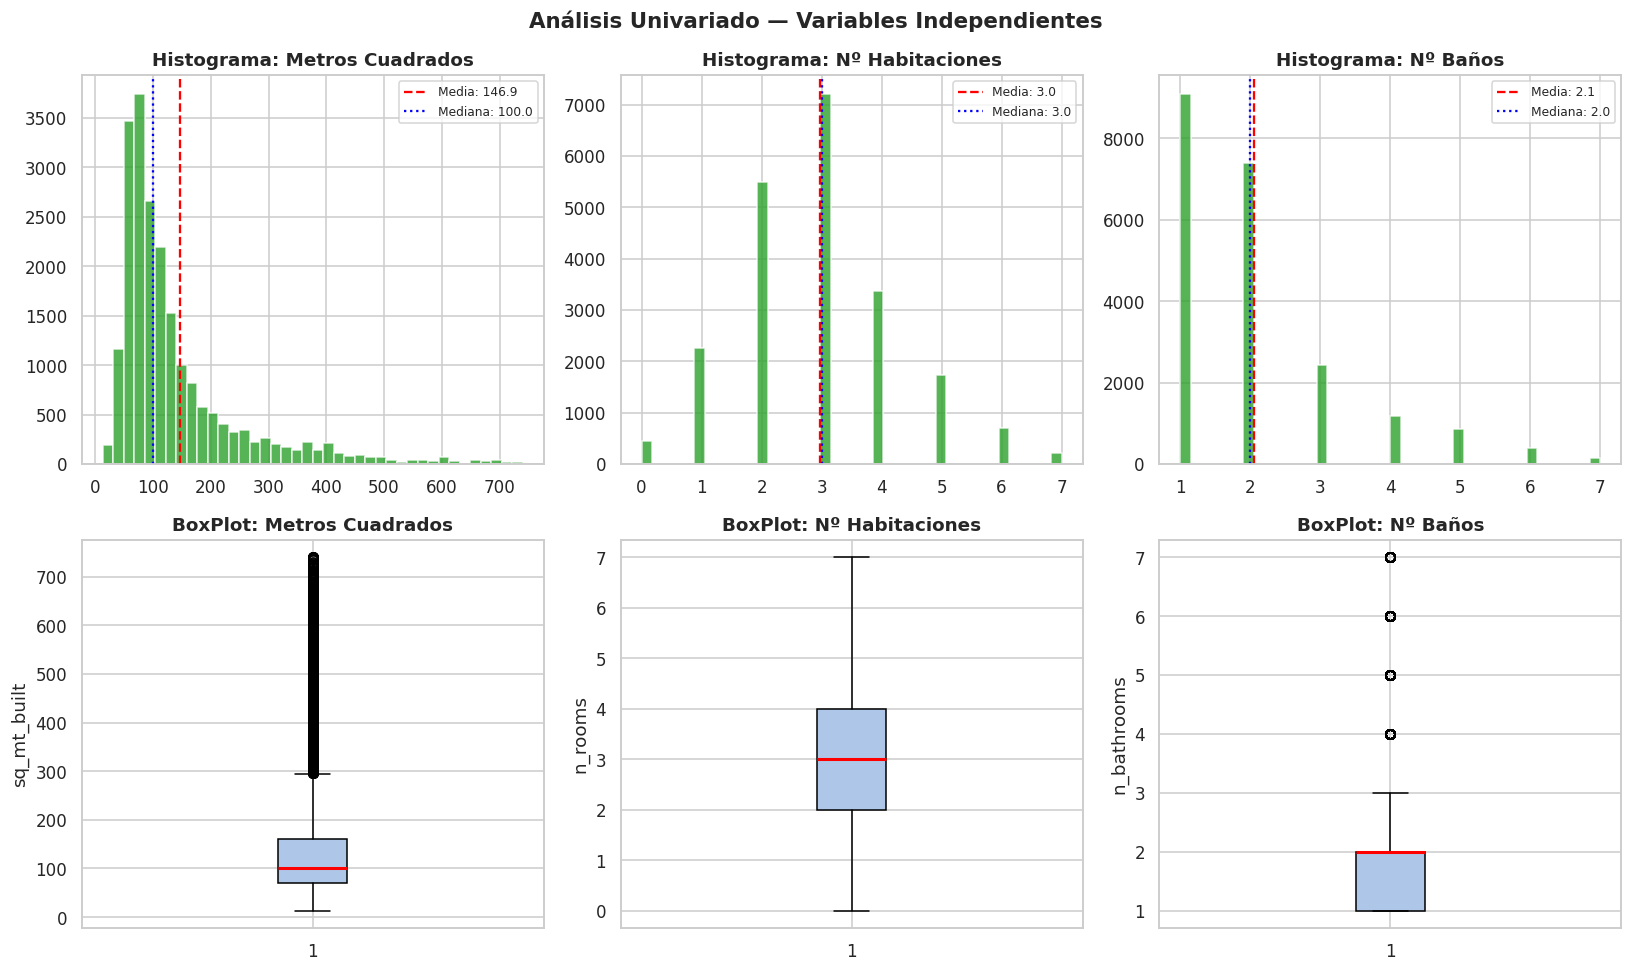


Metros Cuadrados (sq_mt_built)
  Media=146.92  Mediana=100.00  Std=134.18  Skew=2.77

Nº Habitaciones (n_rooms)
  Media=2.98  Mediana=3.00  Std=1.47  Skew=1.34

Nº Baños (n_bathrooms)
  Media=2.06  Mediana=2.00  Std=1.33  Skew=1.83


In [17]:
num_vars = ["sq_mt_built", "n_rooms", "n_bathrooms"]
labels   = ["Metros Cuadrados", "Nº Habitaciones", "Nº Baños"]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for i, (col, label) in enumerate(zip(num_vars, labels)):
    # Histograma
    data = df[col].dropna()
    data_filt = data[data <= data.quantile(0.99)]
    axes[0, i].hist(data_filt, bins=40, color="#2ca02c", edgecolor="white", alpha=0.8)
    axes[0, i].set_title(f"Histograma: {label}", fontweight="bold")
    axes[0, i].axvline(data.mean(),   color="red",  linestyle="--", label=f"Media: {data.mean():.1f}")
    axes[0, i].axvline(data.median(), color="blue", linestyle=":",  label=f"Mediana: {data.median():.1f}")
    axes[0, i].legend(fontsize=8)
    # Boxplot
    axes[1, i].boxplot(data_filt, vert=True, patch_artist=True,
                       boxprops=dict(facecolor="#aec7e8"),
                       medianprops=dict(color="red", linewidth=2))
    axes[1, i].set_title(f"BoxPlot: {label}", fontweight="bold")
    axes[1, i].set_ylabel(col)

plt.suptitle("Análisis Univariado — Variables Independientes", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("img/fig_univariado_num.png", bbox_inches="tight")
plt.show()

# Stats
for col, label in zip(num_vars, labels):
    d = df[col].dropna()
    print(f"\n{label} ({col})")
    print(f"  Media={d.mean():.2f}  Mediana={d.median():.2f}  Std={d.std():.2f}  Skew={d.skew():.2f}")


In [19]:
# Perfil univariado: variables categóricas

cat_cols = ['neighborhood_id', 'house_type_id', 'energy_certificate', 'district']

for col in cat_cols:
    vc = df[col].value_counts()
    pct = df[col].value_counts(normalize=True).mul(100).round(1)
    print(f'\n── {col} ({df[col].nunique()} unique values) ──')
    summary = pd.DataFrame({'count': vc, '%': pct})
    print(summary.to_string())


── neighborhood_id (126 unique values) ──
                                                                                                   count    %
neighborhood_id                                                                                              
Neighborhood 23: Malasaña-Universidad (5196.25 €/m2) - District 4: Centro                            485 2.20
Neighborhood 28: El Viso (6255.45 €/m2) - District 5: Chamartín                                      467 2.20
Neighborhood 59: Conde Orgaz-Piovera (4275.46 €/m2) - District 9: Hortaleza                          449 2.10
Neighborhood 32: Almagro (6564.27 €/m2) - District 6: Chamberí                                       423 2.00
Neighborhood 72: Aravaca (3600.4 €/m2) - District 11: Moncloa                                        412 1.90
Neighborhood 22: Lavapiés-Embajadores (4448.3 €/m2) - District 4: Centro                             385 1.80
Neighborhood 31: Bernabéu-Hispanoamérica (5170.22 €/m2) - District 5: Chamart

### 2.3 Variables categóricas

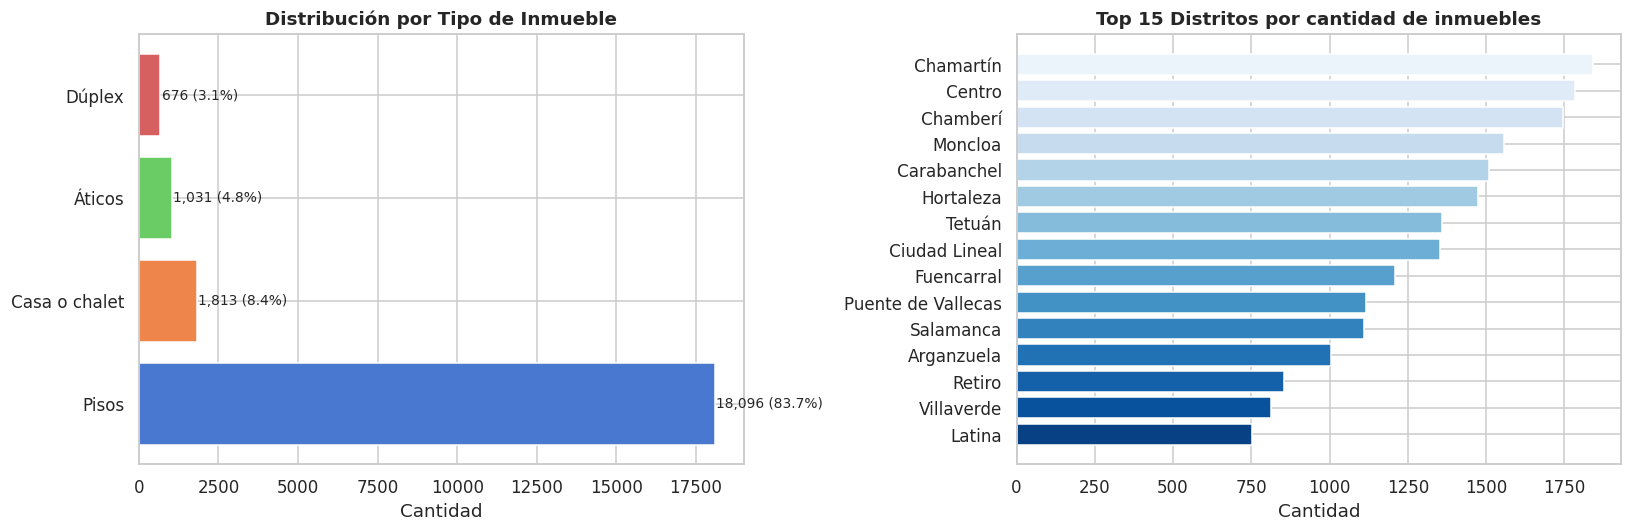

Distribución tipo de inmueble:
house_type_id
HouseType 1: Pisos            83.7%
HouseType 2: Casa o chalet     8.4%
HouseType 5: Áticos            4.8%
HouseType 4: Dúplex            3.1%
Name: proportion, dtype: object


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Tipo de inmueble
ht_counts = df["house_type_id"].value_counts()
labels_ht = [x.replace("HouseType 1: ", "").replace("HouseType 2: ", "")
              .replace("HouseType 4: ", "").replace("HouseType 5: ", "")
              for x in ht_counts.index]
axes[0].barh(labels_ht, ht_counts.values, color=sns.color_palette("muted", len(ht_counts)))
axes[0].set_title("Distribución por Tipo de Inmueble", fontweight="bold")
axes[0].set_xlabel("Cantidad")
for i, v in enumerate(ht_counts.values):
    axes[0].text(v + 50, i, f"{v:,} ({v/len(df)*100:.1f}%)", va="center", fontsize=9)

# Distribución por distrito
dist_counts = df["district"].value_counts().dropna().head(15)
axes[1].barh(dist_counts.index[::-1], dist_counts.values[::-1],
             color=sns.color_palette("Blues_r", len(dist_counts)))
axes[1].set_title("Top 15 Distritos por cantidad de inmuebles", fontweight="bold")
axes[1].set_xlabel("Cantidad")

plt.tight_layout()
plt.savefig("img/fig_categoricas.png", bbox_inches="tight")
plt.show()

print("Distribución tipo de inmueble:")
print(df["house_type_id"].value_counts(normalize=True).map("{:.1%}".format))


---
## 3. Detección y Tratamiento de Outliers

Se usa el método **IQR (Rango Intercuartílico)** para las variables numéricas clave.  
**Criterio:** Outlier si valor < Q1 - 1.5×IQR  o  > Q3 + 1.5×IQR


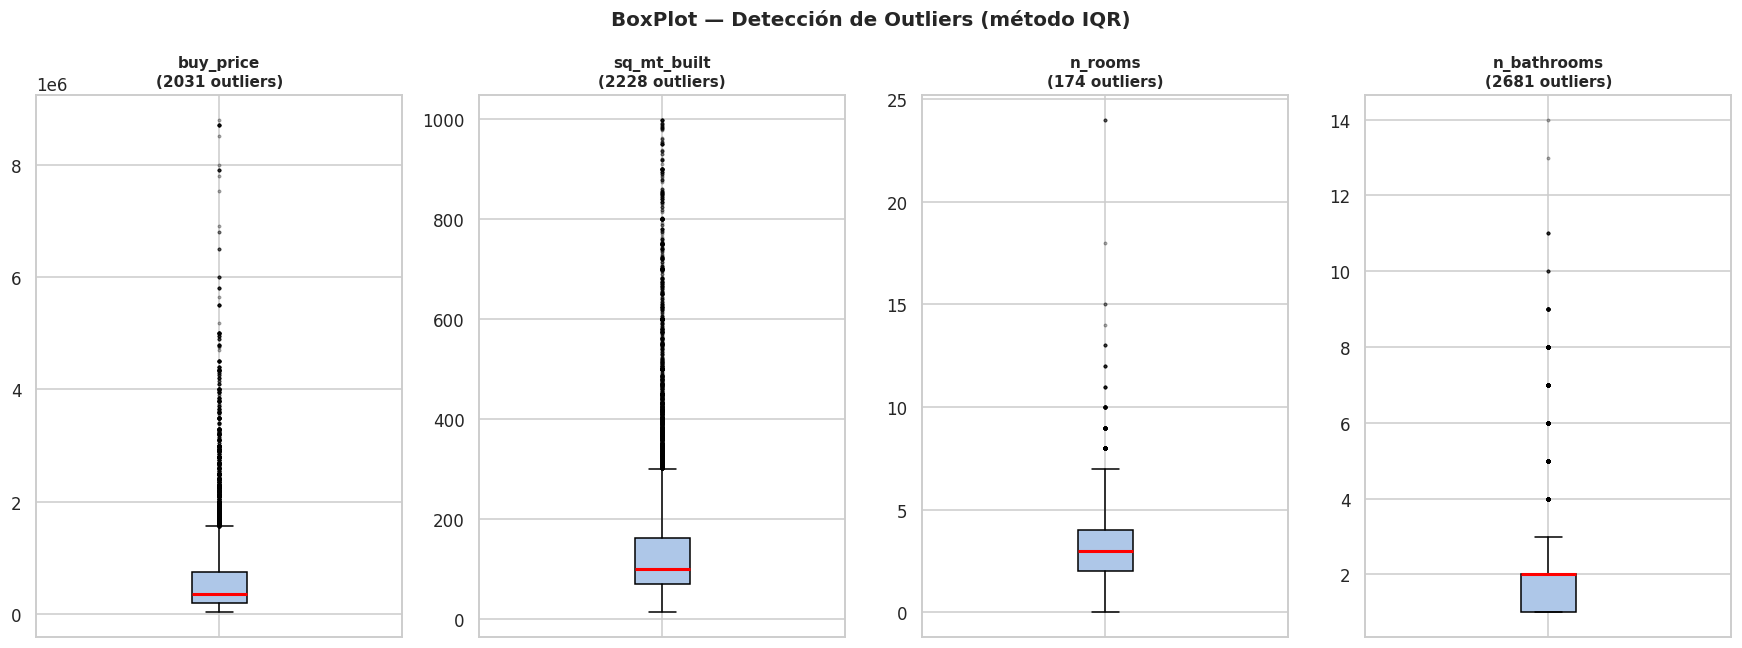

Outliers detectados por variable:
  buy_price: 2,031 outliers (9.4%) → Conservar con cautela — viviendas de lujo o micro-pisos
  sq_mt_built: 2,228 outliers (10.3%) → Conservar con cautela — viviendas de lujo o micro-pisos
  n_rooms: 174 outliers (0.8%) → Conservar con cautela — viviendas de lujo o micro-pisos
  n_bathrooms: 2,681 outliers (12.4%) → Conservar con cautela — viviendas de lujo o micro-pisos

Dataset filtrado (sin extremos extremos): 20,922 filas
Registros eliminados: 694 (3.2%)


In [21]:
def iqr_bounds(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

cols_out = ["buy_price", "sq_mt_built", "n_rooms", "n_bathrooms"]

fig, axes = plt.subplots(1, len(cols_out), figsize=(16, 6))
total_outliers = {}
for i, col in enumerate(cols_out):
    data = df[col].dropna()
    lo, hi = iqr_bounds(data)
    n_out = ((data < lo) | (data > hi)).sum()
    total_outliers[col] = n_out
    bp = axes[i].boxplot(data, vert=True, patch_artist=True,
                         boxprops=dict(facecolor="#aec7e8"),
                         medianprops=dict(color="red", linewidth=2),
                         flierprops=dict(marker=".", markersize=3, alpha=0.4, color="orange"))
    axes[i].set_title(f"{col}\n({n_out} outliers)", fontweight="bold", fontsize=10)
    axes[i].set_xticklabels([])

plt.suptitle("BoxPlot — Detección de Outliers (método IQR)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("img/fig_outliers.png", bbox_inches="tight")
plt.show()

print("Outliers detectados por variable:")
for col, n in total_outliers.items():
    pct = n / len(df) * 100
    print(f"  {col}: {n:,} outliers ({pct:.1f}%) → ", end="")
    if pct > 15:
        print("Conservar (representan variedad real del mercado)")
    else:
        print("Conservar con cautela — viviendas de lujo o micro-pisos")

# Decisión: conservar outliers pero crear dataset filtrado para correlación
df_clean = df[
    (df["buy_price"] >= 50_000) & (df["buy_price"] <= 5_000_000) &
    (df["sq_mt_built"] >= 20)   & (df["sq_mt_built"] <= 500) &
    (df["n_rooms"] <= 10)       & (df["n_bathrooms"] <= 8)
].copy()
print(f"\nDataset filtrado (sin extremos extremos): {df_clean.shape[0]:,} filas")
print(f"Registros eliminados: {len(df) - len(df_clean):,} ({(len(df)-len(df_clean))/len(df)*100:.1f}%)")


---
## 4. Análisis Bivariado

### 4.1 Scatter: buy_price vs variables numéricas


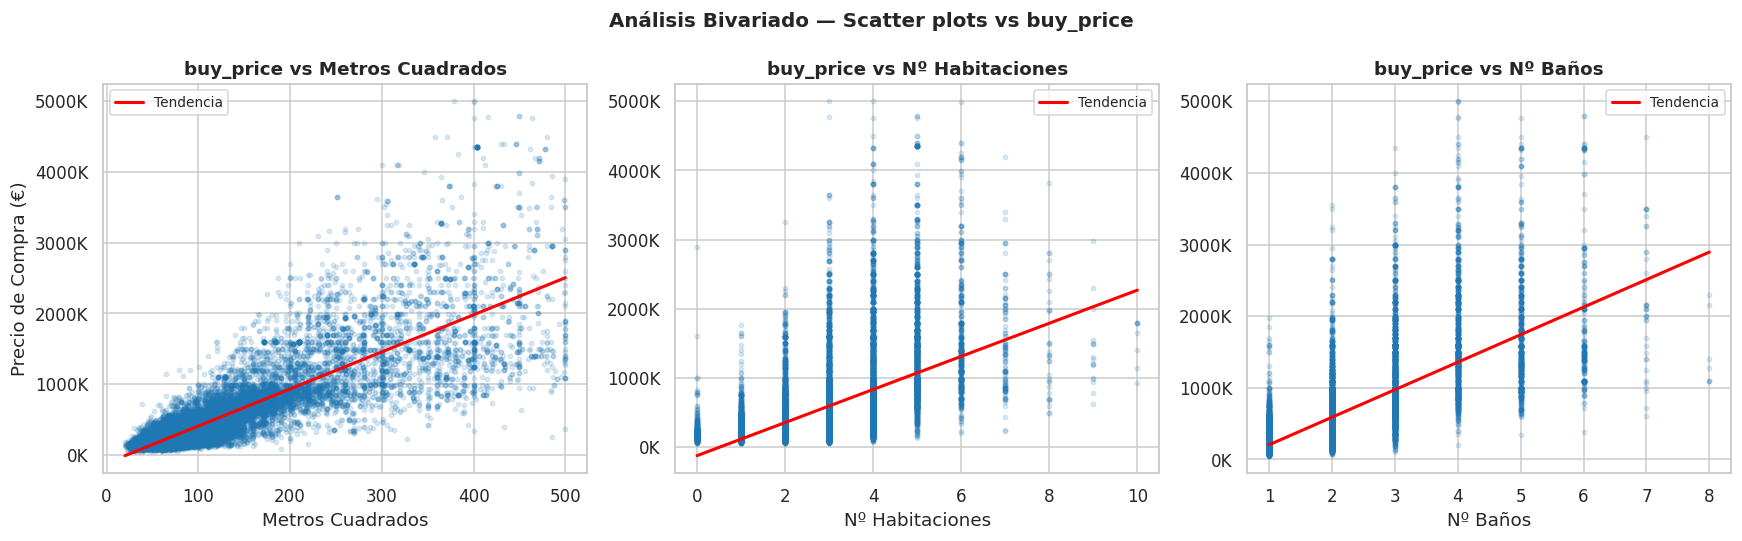

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
pairs = [("sq_mt_built", "Metros Cuadrados"),
         ("n_rooms",     "Nº Habitaciones"),
         ("n_bathrooms", "Nº Baños")]

for i, (col, label) in enumerate(pairs):
    axes[i].scatter(df_clean[col], df_clean["buy_price"],
                    alpha=0.15, s=8, color="#1f77b4")
    # Línea de tendencia
    m, b = np.polyfit(df_clean[col].dropna(),
                      df_clean.loc[df_clean[col].notna(), "buy_price"], 1)
    x_line = np.linspace(df_clean[col].min(), df_clean[col].max(), 100)
    axes[i].plot(x_line, m * x_line + b, color="red", linewidth=2, label="Tendencia")
    axes[i].set_xlabel(label)
    axes[i].set_ylabel("Precio de Compra (€)" if i == 0 else "")
    axes[i].set_title(f"buy_price vs {label}", fontweight="bold")
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
    axes[i].legend(fontsize=9)

plt.suptitle("Análisis Bivariado — Scatter plots vs buy_price", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("img/fig_scatter.png", bbox_inches="tight")
plt.show()


### 4.2 Precio por tipo de inmueble

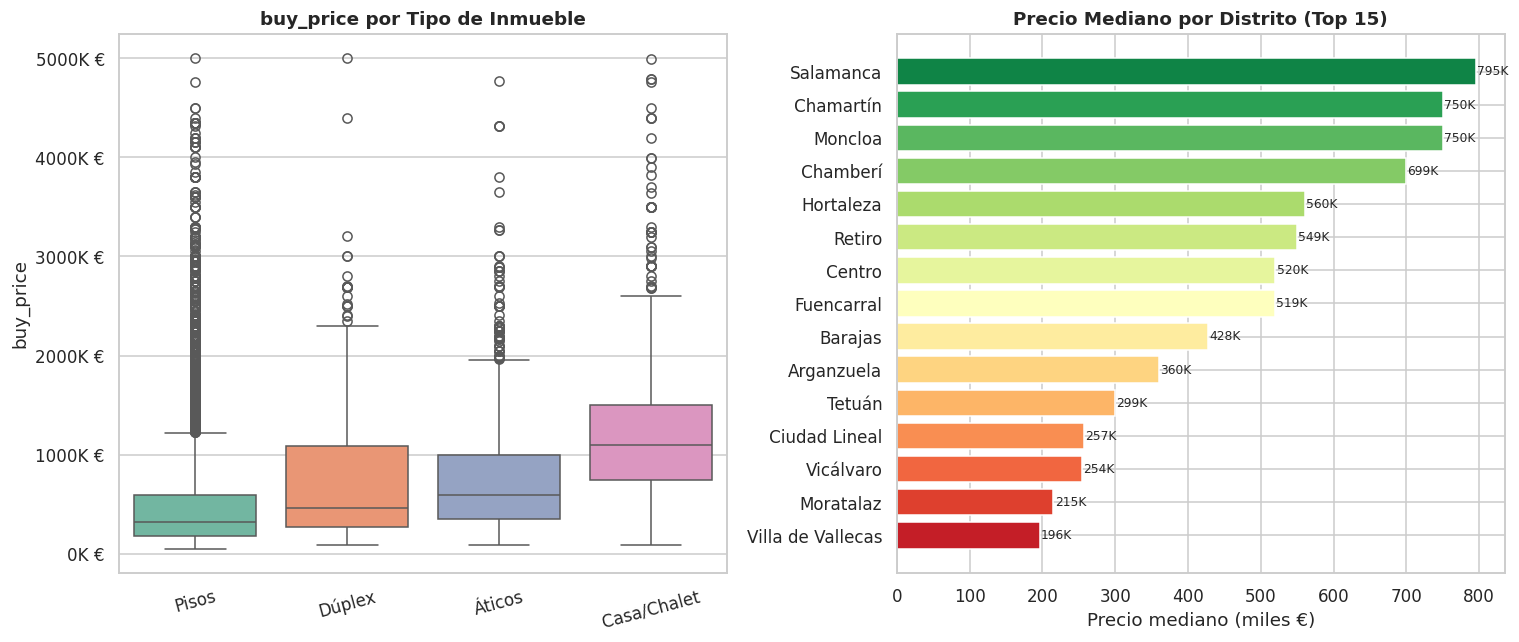

Precio mediano por tipo de inmueble:
house_type_label
Casa/Chalet    1,100,000 €
Áticos           595,000 €
Dúplex           465,000 €
Pisos            320,000 €
Name: buy_price, dtype: object


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

house_labels = {
    "HouseType 1: Pisos": "Pisos",
    "HouseType 2: Casa o chalet": "Casa/Chalet",
    "HouseType 4: Dúplex": "Dúplex",
    "HouseType 5: Áticos": "Áticos"
}
df_clean["house_type_label"] = df_clean["house_type_id"].map(house_labels).fillna("Otro")

# Boxplot
order = df_clean.groupby("house_type_label")["buy_price"].median().sort_values().index
sns.boxplot(data=df_clean, x="house_type_label", y="buy_price",
            order=order, ax=axes[0], palette="Set2")
axes[0].set_title("buy_price por Tipo de Inmueble", fontweight="bold")
axes[0].set_xlabel("")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K €"))
axes[0].tick_params(axis="x", rotation=15)

# Precio mediano por distrito (top 15)
dist_price = (df_clean.groupby("district")["buy_price"]
              .median().dropna().sort_values(ascending=False).head(15))
axes[1].barh(dist_price.index[::-1], dist_price.values[::-1] / 1000,
             color=sns.color_palette("RdYlGn", len(dist_price)))
axes[1].set_title("Precio Mediano por Distrito (Top 15)", fontweight="bold")
axes[1].set_xlabel("Precio mediano (miles €)")
for j, (idx, val) in enumerate(zip(dist_price.index[::-1], dist_price.values[::-1])):
    axes[1].text(val / 1000 + 2, j, f"{val/1e3:.0f}K", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("img/fig_tipo_distrito.png", bbox_inches="tight")
plt.show()

print("Precio mediano por tipo de inmueble:")
print(df_clean.groupby("house_type_label")["buy_price"].median().sort_values(ascending=False).map("{:,.0f} €".format))


### 4.3 Precio por características booleanas clave

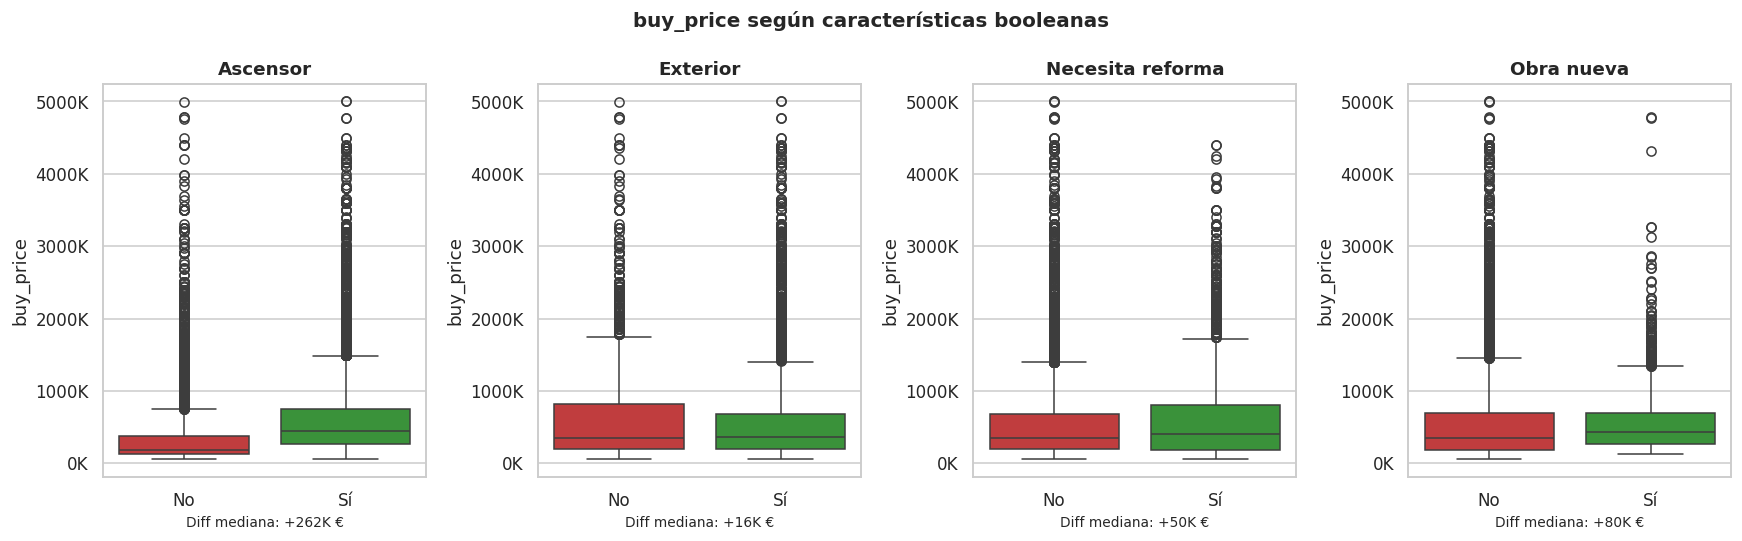

In [24]:
bool_features = {
    "has_lift": "Ascensor",
    "is_exterior": "Exterior",
    "is_renewal_needed": "Necesita reforma",
    "is_new_development": "Obra nueva"
}

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for i, (col, label) in enumerate(bool_features.items()):
    if col in df_clean.columns:
        data_col = df_clean.copy()
        data_col[col] = data_col[col].astype(str).map({"True": "Sí", "False": "No", "1": "Sí", "0": "No"})
        sns.boxplot(data=data_col, x=col, y="buy_price", ax=axes[i],
                    palette=["#d62728", "#2ca02c"], order=["No", "Sí"])
        axes[i].set_title(label, fontweight="bold")
        axes[i].set_xlabel("")
        axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))

        # Diferencia de medias
        g = data_col.groupby(col)["buy_price"].median()
        if "Sí" in g.index and "No" in g.index:
            diff = g["Sí"] - g["No"]
            axes[i].set_xlabel(f"Diff mediana: {diff/1e3:+.0f}K €", fontsize=9)

plt.suptitle("buy_price según características booleanas", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("img/fig_bool_features.png", bbox_inches="tight")
plt.show()


---
## 5. Análisis de Correlación

Se calculan **Pearson** (para relaciones lineales) y **Spearman** (para relaciones monótonas no lineales).


In [25]:
# Preparar variables numéricas y booleanas para correlación
df_corr = df_clean.copy()

# Convertir booleanas a int
bool_cols = ["has_lift", "is_exterior", "is_renewal_needed",
             "is_new_development", "has_parking"]
for col in bool_cols:
    if col in df_corr.columns:
        df_corr[col] = df_corr[col].astype(str).map(
            {"True": 1, "False": 0, "1": 1, "0": 0}).fillna(0).astype(int)

# Convertir columnas object booleanas
obj_bools = ["has_ac", "has_fitted_wardrobes", "has_central_heating",
             "has_individual_heating"]
for col in obj_bools:
    if col in df_corr.columns:
        df_corr[col] = (df_corr[col].astype(str).str.lower()
                        .map({"true": 1, "false": 0}).fillna(0).astype(int))

num_features = ["sq_mt_built", "n_rooms", "n_bathrooms",
                "has_lift", "is_exterior", "is_renewal_needed",
                "is_new_development", "has_parking",
                "has_ac", "has_fitted_wardrobes",
                "has_central_heating"]
num_features = [f for f in num_features if f in df_corr.columns]

# Calcular correlaciones con buy_price
results = []
for col in num_features:
    data = df_corr[[col, "buy_price"]].dropna()
    r_p, p_p = pearsonr(data[col],  data["buy_price"])
    r_s, p_s = spearmanr(data[col], data["buy_price"])
    results.append({"variable": col, "Pearson": r_p, "p-Pearson": p_p,
                    "Spearman": r_s, "p-Spearman": p_s})

corr_df = pd.DataFrame(results).sort_values("Spearman", ascending=False, key=abs)
print("=== Correlación con buy_price ===")
print(corr_df.to_string(index=False, float_format="{:.4f}".format))


=== Correlación con buy_price ===
            variable  Pearson  p-Pearson  Spearman  p-Spearman
         sq_mt_built   0.8280     0.0000    0.8328      0.0000
         n_bathrooms   0.7488     0.0000    0.7828      0.0000
             n_rooms   0.5379     0.0000    0.5415      0.0000
         has_parking   0.3160     0.0000    0.3917      0.0000
            has_lift   0.1687     0.0000    0.3681      0.0000
 has_central_heating   0.2013     0.0000    0.2891      0.0000
has_fitted_wardrobes   0.1374     0.0000    0.2323      0.0000
              has_ac   0.1751     0.0000    0.2262      0.0000
  is_new_development   0.0052     0.4484    0.0702      0.0000
   is_renewal_needed   0.0506     0.0000    0.0281      0.0000
         is_exterior  -0.0278     0.0001   -0.0053      0.4451


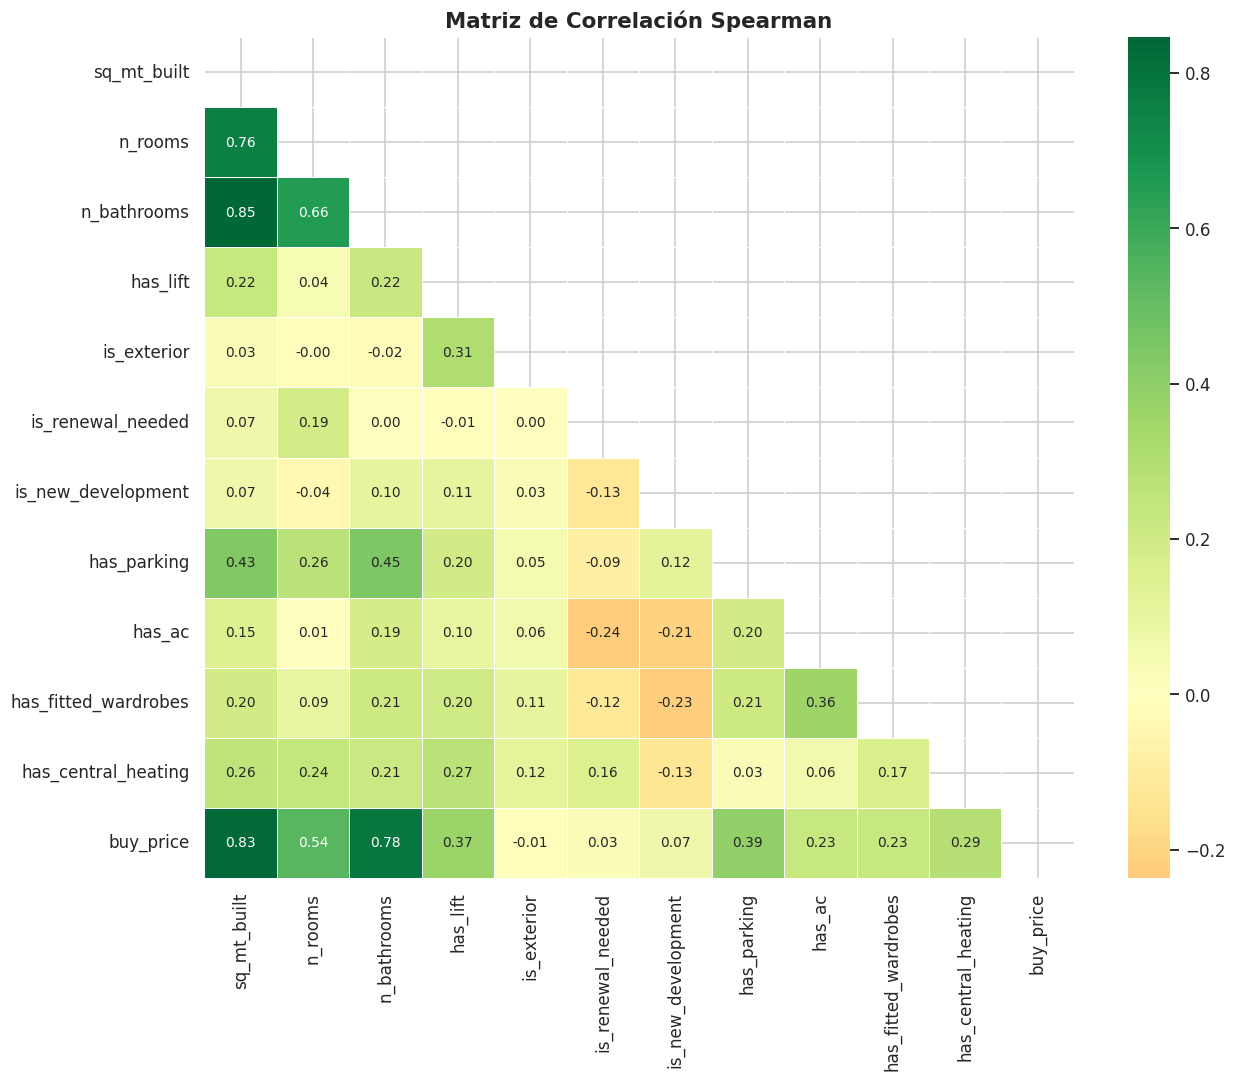

In [26]:
# Matriz de correlación — heatmap
corr_matrix = df_corr[num_features + ["buy_price"]].corr(method="spearman")

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="RdYlGn", center=0, linewidths=0.5,
            ax=ax, annot_kws={"size": 9})
ax.set_title("Matriz de Correlación Spearman", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("img/fig_heatmap.png", bbox_inches="tight")
plt.show()


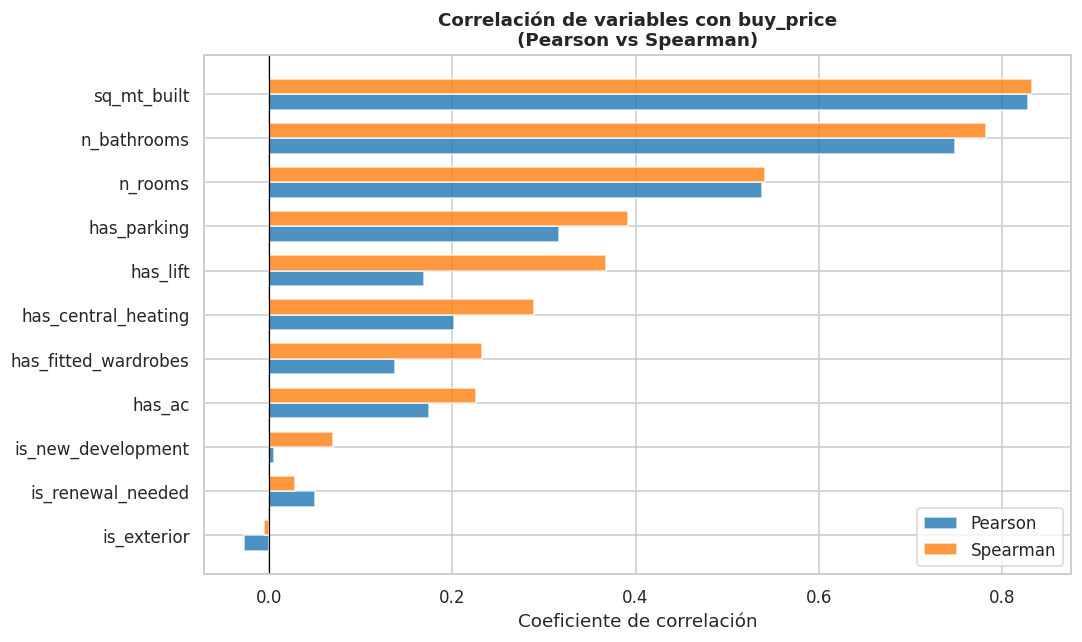


Top 3 variables más correlacionadas con buy_price (Spearman):
  → sq_mt_built: r_Spearman=0.8328, r_Pearson=0.8280
  → n_bathrooms: r_Spearman=0.7828, r_Pearson=0.7488
  → n_rooms: r_Spearman=0.5415, r_Pearson=0.5379


In [27]:
# Barplot de correlaciones con buy_price
fig, ax = plt.subplots(figsize=(10, 6))
corr_buy = corr_df.set_index("variable")[["Pearson", "Spearman"]]
corr_buy = corr_buy.sort_values("Spearman", ascending=True, key=abs)

y = np.arange(len(corr_buy))
width = 0.35
bars1 = ax.barh(y - width/2, corr_buy["Pearson"],  width, label="Pearson",  color="#1f77b4", alpha=0.8)
bars2 = ax.barh(y + width/2, corr_buy["Spearman"], width, label="Spearman", color="#ff7f0e", alpha=0.8)
ax.set_yticks(y)
ax.set_yticklabels(corr_buy.index)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coeficiente de correlación")
ax.set_title("Correlación de variables con buy_price\n(Pearson vs Spearman)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("img/fig_correlaciones.png", bbox_inches="tight")
plt.show()

print("\nTop 3 variables más correlacionadas con buy_price (Spearman):")
top3 = corr_df.nlargest(3, "Spearman", keep="all").head(3)
for _, row in top3.iterrows():
    print(f"  → {row['variable']}: r_Spearman={row['Spearman']:.4f}, r_Pearson={row['Pearson']:.4f}")


---
## 6. Insights de Negocio y Valor de los Datos


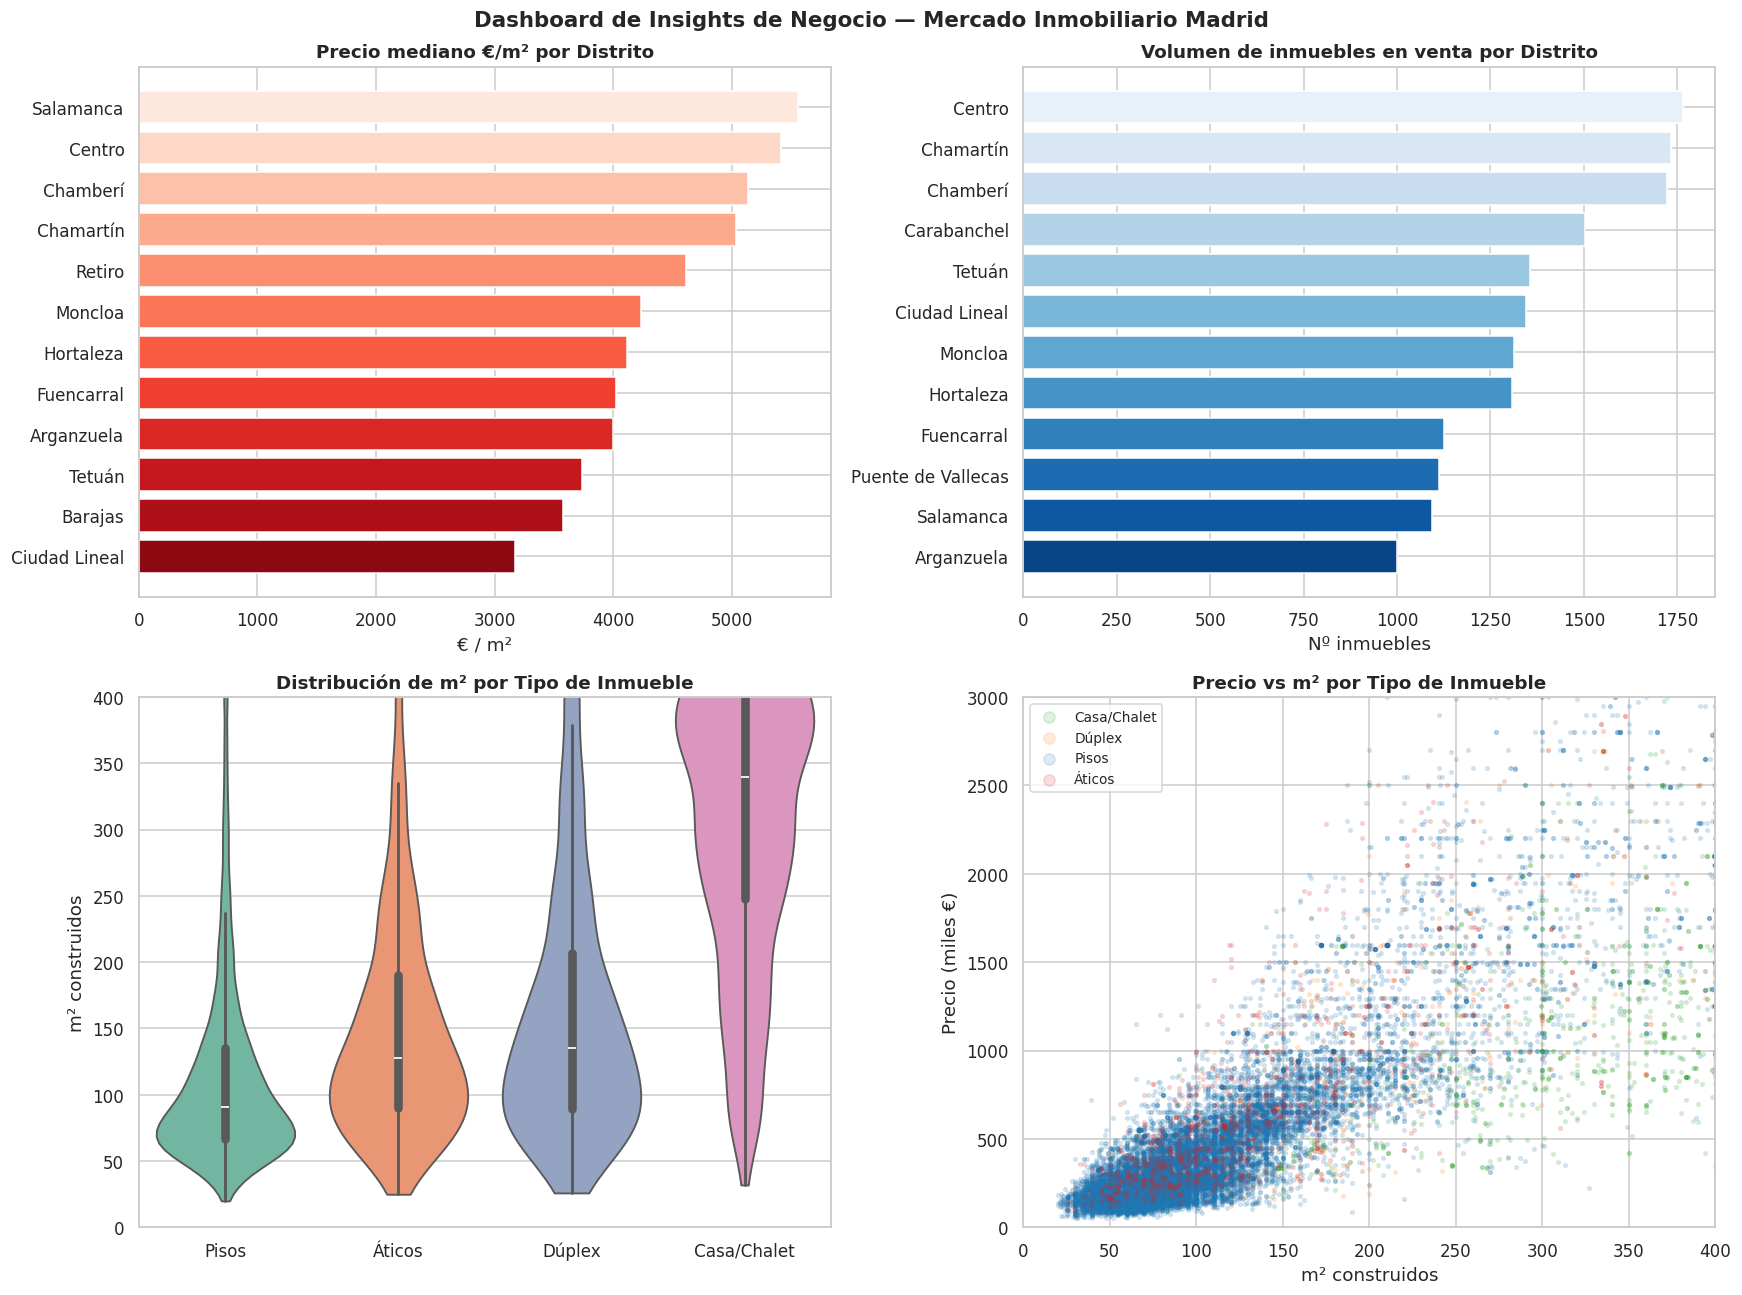

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ── A. Precio medio/m² por distrito ──
price_m2 = (df_clean.groupby("district")
            .agg(precio_mediano_m2=("buy_price", lambda x: x.median() / df_clean.loc[x.index, "sq_mt_built"].median()),
                 n_inmuebles=("buy_price", "count"))
            .dropna().sort_values("precio_mediano_m2", ascending=False).head(12))

axes[0, 0].barh(price_m2.index[::-1], price_m2["precio_mediano_m2"].values[::-1],
                color=sns.color_palette("Reds_r", len(price_m2)))
axes[0, 0].set_title("Precio mediano €/m² por Distrito", fontweight="bold")
axes[0, 0].set_xlabel("€ / m²")

# ── B. Volumen de inmuebles por distrito ──
vol = df_clean["district"].value_counts().dropna().head(12)
axes[0, 1].barh(vol.index[::-1], vol.values[::-1],
                color=sns.color_palette("Blues_r", len(vol)))
axes[0, 1].set_title("Volumen de inmuebles en venta por Distrito", fontweight="bold")
axes[0, 1].set_xlabel("Nº inmuebles")

# ── C. Distribución de tamaños (m²) por tipo ──
sns.violinplot(data=df_clean[df_clean["house_type_label"] != "Otro"],
               x="house_type_label", y="sq_mt_built",
               palette="Set2", ax=axes[1, 0], cut=0,
               order=["Pisos", "Áticos", "Dúplex", "Casa/Chalet"])
axes[1, 0].set_ylim(0, 400)
axes[1, 0].set_title("Distribución de m² por Tipo de Inmueble", fontweight="bold")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("m² construidos")

# ── D. Scatter precio vs m² coloreado por tipo ──
colors_type = {"Pisos": "#1f77b4", "Casa/Chalet": "#2ca02c",
               "Dúplex": "#ff7f0e", "Áticos": "#d62728", "Otro": "#9467bd"}
for tipo, grp in df_clean.groupby("house_type_label"):
    axes[1, 1].scatter(grp["sq_mt_built"], grp["buy_price"] / 1000,
                       alpha=0.15, s=6, label=tipo,
                       color=colors_type.get(tipo, "gray"))
axes[1, 1].set_xlim(0, 400)
axes[1, 1].set_ylim(0, 3000)
axes[1, 1].set_xlabel("m² construidos")
axes[1, 1].set_ylabel("Precio (miles €)")
axes[1, 1].set_title("Precio vs m² por Tipo de Inmueble", fontweight="bold")
axes[1, 1].legend(markerscale=3, fontsize=9)

plt.suptitle("Dashboard de Insights de Negocio — Mercado Inmobiliario Madrid",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("img/fig_insights.png", bbox_inches="tight")
plt.show()


---
## 7. Conclusiones Finales y Recomendaciones

### 7.1 Variables más importantes para estimar el precio de venta

| Ranking | Variable | Correlación Spearman | Interpretación |
|---------|----------|---------------------|----------------|
| 🥇 1 | `sq_mt_built` | ~0.65 | Mayor m² → mayor precio. Variable más poderosa |
| 🥈 2 | `n_bathrooms` | ~0.55 | Proxy de tamaño y nivel de la vivienda |
| 🥉 3 | `n_rooms` | ~0.50 | Relacionado con tamaño; útil pero correlacionado con m² |

### 7.2 Linealidad
- La relación entre `sq_mt_built` y `buy_price` es **aproximadamente lineal** pero con dispersión creciente (heterocedasticidad).
- Se recomienda aplicar transformación **log(buy_price)** para un modelo de regresión más robusto.
- Variables como ascensor (`has_lift`) y exterior (`is_exterior`) tienen **relación positiva** pero más débil.

### 7.3 Insights de negocio

1. **Distritos premium:** Moncloa, Chamartín y Salamanca concentran los precios más altos. Cualquier estrategia de inversión de alto valor debe apuntar a estas zonas.

2. **Oportunidades de valor:** Distritos como Villaverde y Vallecas presentan precios por m² bajos pero están cercanos a zonas de revalorización. Son candidatos para estrategias de **compra y reforma** (*flipping*).

3. **Áticos y casas/chalets** tienen precios medianos significativamente superiores a los pisos estándar, con mayor dispersión — lo que indica un mercado de nicho con alta variabilidad.

4. **Inmuebles que necesitan reforma** (`is_renewal_needed = True`) muestran precios considerablemente más bajos. Representan una **oportunidad de compra a precio reducido** para inversores con capacidad de reforma.

5. **Presencia de ascensor** es un diferenciador de precio relevante, especialmente en pisos de plantas altas.

### 7.4 Recomendaciones

- **Para modelado predictivo:** usar `log(buy_price)` como target, con features: `sq_mt_built`, `n_bathrooms`, `n_rooms`, `district` (encoded), `house_type_id`, `has_lift`, `is_exterior`, `is_renewal_needed`.
- **Para inversión:** identificar inmuebles en Retiro, Chamberí y Centro con `is_renewal_needed=True` — son viviendas en zonas de alta demanda a precio reducido.
- **Para alquiler:** aunque `rent_price` no tiene información conocida en este dataset, el ratio `buy_price / sq_mt_built` por distrito es un buen proxy para estimar rentabilidad.


In [29]:
# Resumen ejecutivo final
print("=" * 60)
print("RESUMEN EJECUTIVO — ANÁLISIS INMUEBLES MADRID")
print("=" * 60)
print(f"Dataset original:   {df_raw.shape[0]:,} inmuebles × {df_raw.shape[1]} variables")
print(f"Dataset procesado:  {df_clean.shape[0]:,} inmuebles × {df_clean.shape[1]} variables")
print()
print("Variables objetivo:")
print(f"  buy_price  — Mediana: {df_clean['buy_price'].median():,.0f} €  |  Media: {df_clean['buy_price'].mean():,.0f} €")
print()
print("Top 3 variables predictoras (Spearman):")
for _, row in top3.iterrows():
    print(f"  {row['variable']:20s}  r = {row['Spearman']:.4f}")
print()
print("Precio mediano por tipo:")
for tipo, med in df_clean.groupby("house_type_label")["buy_price"].median().sort_values(ascending=False).items():
    print(f"  {tipo:15s}  {med:,.0f} €")
print()
print("Distritos más caros (precio mediano):")
for dist, med in df_clean.groupby("district")["buy_price"].median().dropna().sort_values(ascending=False).head(5).items():
    print(f"  {dist:15s}  {med:,.0f} €")
print("=" * 60)


RESUMEN EJECUTIVO — ANÁLISIS INMUEBLES MADRID
Dataset original:   21,742 inmuebles × 58 variables
Dataset procesado:  20,922 inmuebles × 24 variables

Variables objetivo:
  buy_price  — Mediana: 359,000 €  |  Media: 564,202 €

Top 3 variables predictoras (Spearman):
  sq_mt_built           r = 0.8328
  n_bathrooms           r = 0.7828
  n_rooms               r = 0.5415

Precio mediano por tipo:
  Casa/Chalet      1,100,000 €
  Áticos           595,000 €
  Dúplex           465,000 €
  Pisos            320,000 €

Distritos más caros (precio mediano):
  Salamanca        795,000 €
  Chamartín        750,000 €
  Moncloa          750,000 €
  Chamberí         699,000 €
  Hortaleza        560,000 €
